# Introvert vs Extrovert Personality Prediction

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

In [58]:
DATA_PATH = "data/personality_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [59]:
print("Dataset shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("Missing values:")
print(df.isna().sum())
print("Target distribution:")
print(df["Personality"].value_counts())

Dataset shape: (2900, 8)
Columns:
['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality']
Missing values:
Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64
Target distribution:
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64


In [60]:
df_clean = df.copy()

TARGET = "Personality"
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
Categorical features: ['Stage_fear', 'Drained_after_socializing']


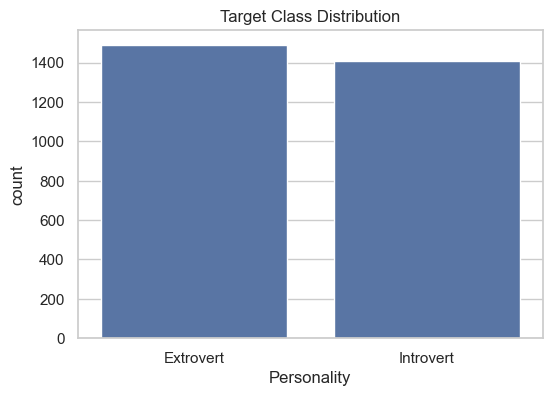

In [61]:
# Target balance
plt.figure(figsize=(6,4))
sns.countplot(data=df_clean, x="Personality")
plt.title("Target Class Distribution")
plt.show()

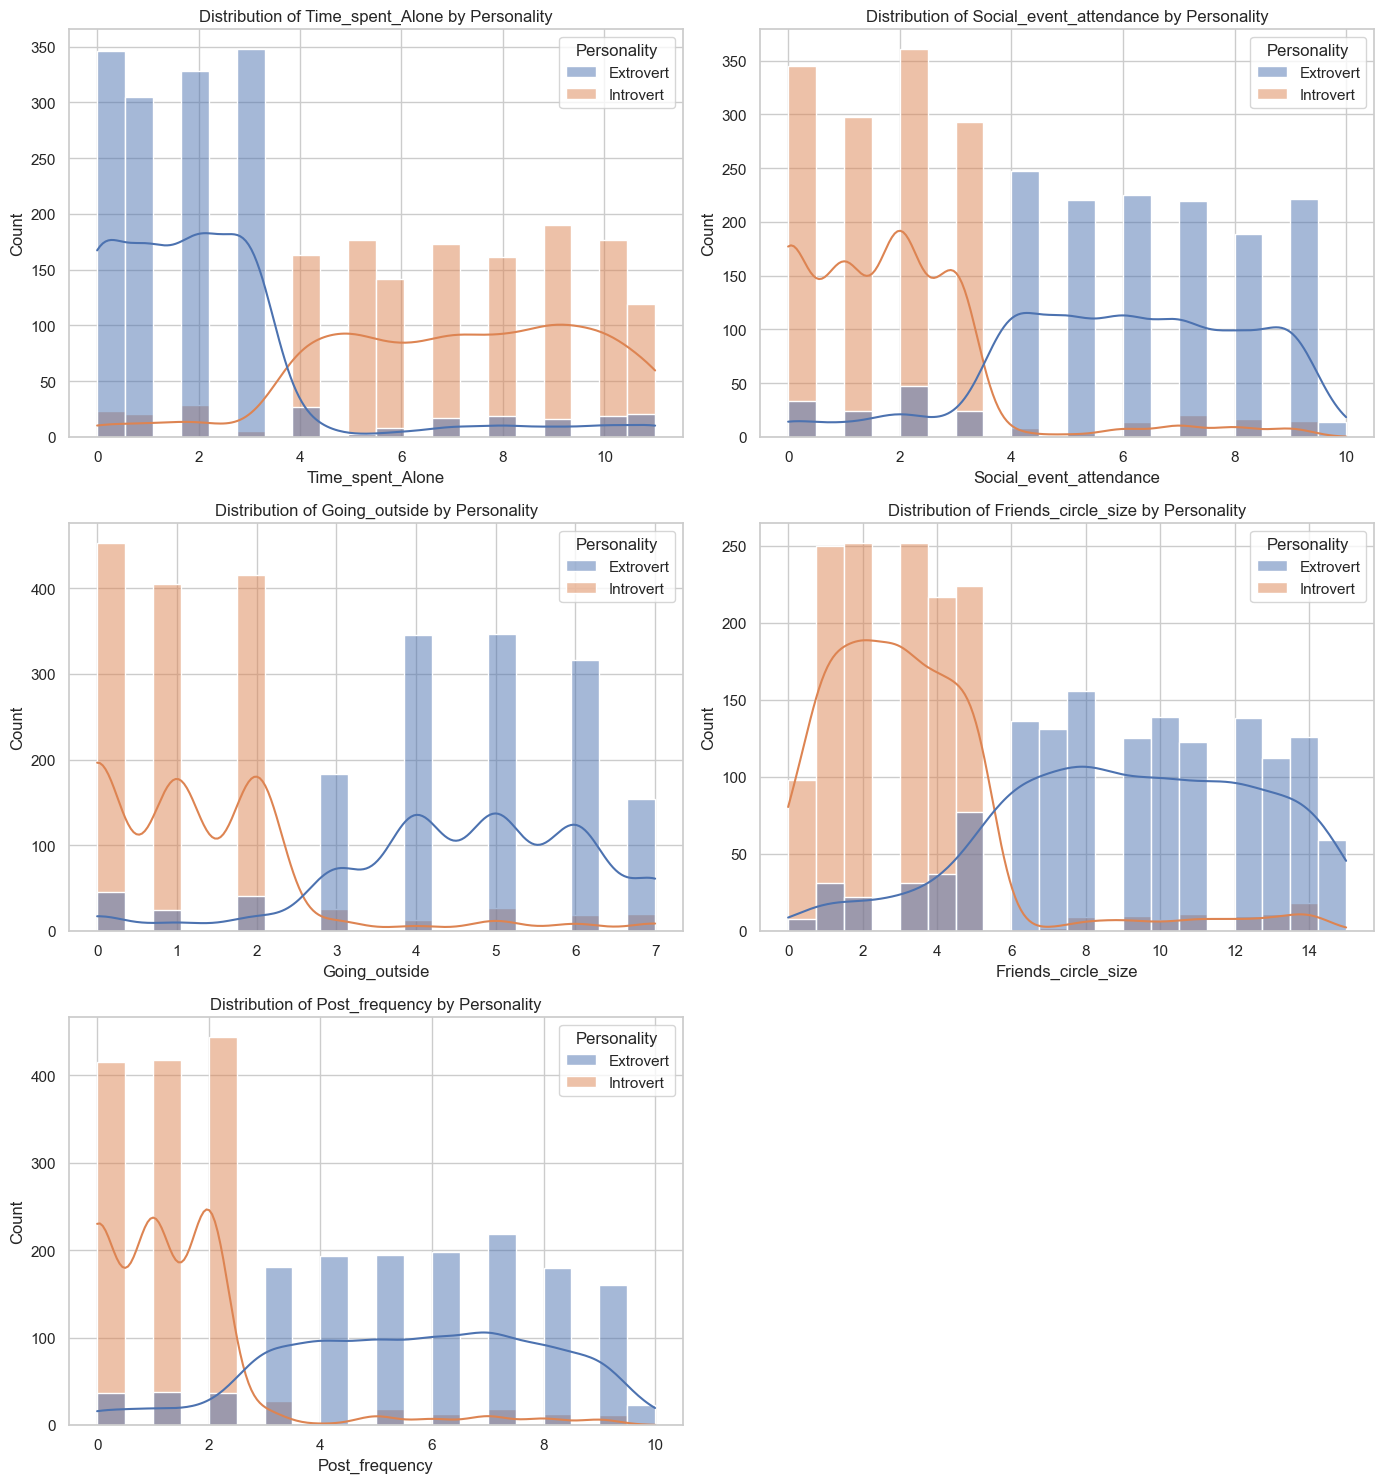

In [62]:
# Numerical feature distributions by target
n_cols = 2
n_rows = math.ceil(len(numeric_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(numeric_features):
    sns.histplot(
        data=df_clean,
        x=col,
        hue="Personality",
        kde=True,
        bins=20,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col} by Personality")
# Remove unused subplots
for j in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

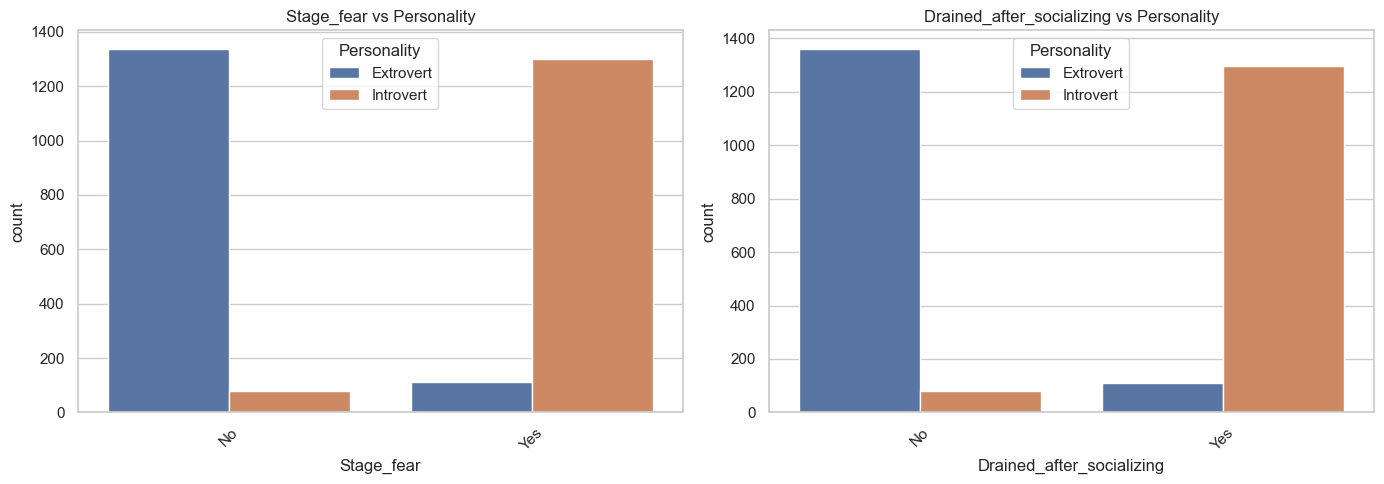

In [63]:
# Categorical feature relationships
n_cols = 2
n_rows = math.ceil(len(categorical_features) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(categorical_features):
    sns.countplot(
        data=df_clean,
        x=col,
        hue="Personality",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Personality")
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

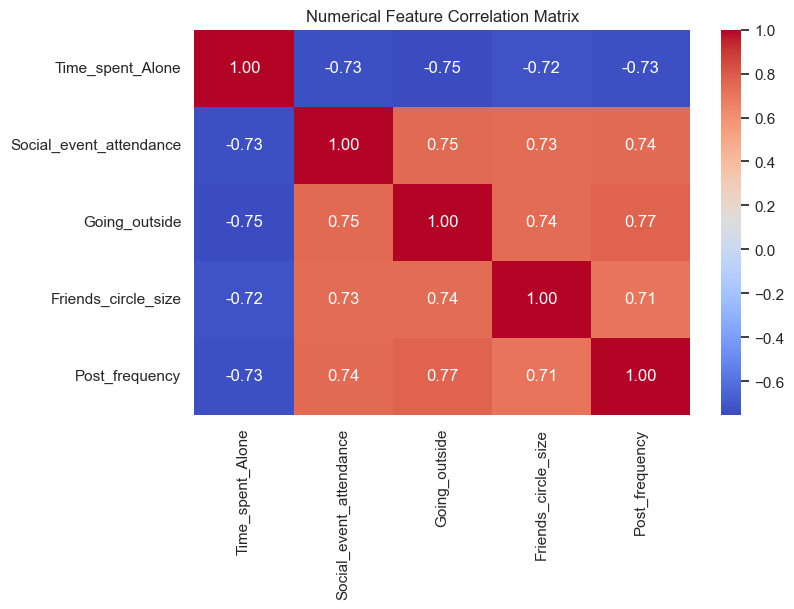

In [64]:
# Correlation check for numerical variables
plt.figure(figsize=(8,5))
sns.heatmap(df_clean[numeric_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numerical Feature Correlation Matrix")
plt.show()

In [65]:
# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

In [66]:
# Compare multiple models using stratified 5-fold cross-validation
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe, X, y, cv=cv,
        scoring=["accuracy", "f1_weighted", "roc_auc_ovo_weighted"],
        n_jobs=1
    )
    results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_f1_weighted_mean": scores["test_f1_weighted"].mean(),
        "cv_f1_weighted_std": scores["test_f1_weighted"].std(),
        "cv_roc_auc_mean": scores["test_roc_auc_ovo_weighted"].mean(),
    })

results_df = pd.DataFrame(results).sort_values(["cv_f1_weighted_mean", "cv_roc_auc_mean"], ascending=False)
display(results_df)

,model,cv_accuracy_mean,cv_accuracy_std,cv_f1_weighted_mean,cv_f1_weighted_std,cv_roc_auc_mean
3,Gradient Boosting,0.934483,0.011227,0.934489,0.011223,0.964783
1,Random Forest,0.934483,0.010229,0.934489,0.010224,0.964628
0,Logistic Regression,0.926552,0.008489,0.926555,0.008476,0.931075
2,Extra Trees,0.919310,0.004803,0.919293,0.004797,0.931558
